# Análise ConnectaTel

Como **analista de dados**, seu objetivo é avaliar o **comportamento dos clientes** de uma empresa de telecomunicações na América Latina, a ConnectaTel.

Trabalharemos com informações registradas **até o ano de 2024**, o que permitirá analisar o comportamento do negócio dentro desse período.

Para isso, você trabalhará com três datasets:  

- **plans.csv** → informações dos planos atuais (preço, minutos incluídos, GB incluídos, custo por extra)  
- **users.csv** → informações dos clientes (idade, cidade, data de cadastro, plano, churn)  
- **usage.csv** → detalhe do **uso real** dos serviços (chamadas e mensagens)  

Você deverá **explorar**, **limpar** e **analisar** esses dados para construir um **perfil estatístico** dos clientes, detectar **comportamentos atípicos** e criar **segmentos de clientes**.  

Essa análise permitirá **identificar padrões de consumo**, **desenhar estratégias de retenção** e **sugerir melhorias nos planos** oferecidos pela empresa.

> 💡 Antes de começar, lembre-se de pensar de forma **programática**: quais etapas são necessárias? Em que ordem? O que você quer medir e por quê?


---
## 🧩 Etapa 1: Carregar e explorar

Antes de limpar ou combinar os dados, é necessário **familiarizar-se com a estrutura dos três datasets**.  
Nesta etapa, você validará se os arquivos foram carregados corretamente, conhecerá suas colunas e tipos de dados e detectará possíveis inconsistências.

### 1.1 Carregamento de dados e visualização rápida

**🎯 Objetivo:**  
Ter os **3 datasets prontos na memória**, entender seu conteúdo e realizar uma revisão preliminar.

**Instruções:**  
- Importe as bibliotecas necessárias (por exemplo, `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carregue os arquivos CSV usando `pd.read_csv()`:
  - **`https://practicum-content.s3.us-west-1.amazonaws.com/datasets/plans.csv`**  
  - **`https://practicum-content.s3.us-west-1.amazonaws.com/datasets/users_brasil.csv`**  
  - **`https://practicum-content.s3.us-west-1.amazonaws.com/datasets/usage.csv`**  
- Salve os DataFrames nas variáveis: `plans`, `users`, `usage`.  
- Mostre as primeiras linhas de cada DataFrame usando `.head()`.


In [4]:
# importar bibliotecas
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

In [5]:
# carregar arquivos
plans = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/plans.csv')
users = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/users_brasil.csv')
usage = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/usage.csv')

In [6]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Santos,38,São Paulo,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Matheus,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Valentina,Souza,57,Brasília,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Matheus,Souza,69,Rio de Janeiro,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Matheus,Torres,63,Fortaleza,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Dica:** Se você não usar `print()`, a tabela será exibida melhor.

### 1.2 Exploração da estrutura dos datasets

**🎯 Objetivo:**  
Conhecer a **estrutura de cada dataset**, revisar quantas linhas e colunas eles têm, identificar os **tipos de dados** de cada coluna e detectar possíveis **inconsistências ou valores ausentes** antes de iniciar a análise.

**Instruções:**  
- Revise o **número de linhas e colunas** de cada dataset usando `.shape`.  
- Use `.info()` em cada DataFrame para obter um **resumo completo** de colunas, tipos de dados e valores não nulos.  

In [9]:
# revisar o número de linhas e colunas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩 Etapa 2: Identificação de problemas de qualidade dos dados

### 2.1 Revisão de valores ausentes

**🎯 Objetivo:**  
Detectar a presença e a magnitude de valores ausentes para avaliar se eles afetam a análise ou exigem imputação/remoção.

**Instruções:**  
- Conte os valores ausentes por coluna para cada dataset.
- Calcule a proporção de valores ausentes por coluna para cada dataset.

O dataset `plans` tem apenas 2 linhas e podemos observar que não possui valores ausentes, por isso não precisa de exploração adicional.

<br>
<details>
<summary>Clique para ver a dica</summary>
Use `.isna().sum()` para contar valores ausentes e `.isna().mean()` para calcular a proporção.


In [16]:
# quantidade de valores ausentes para users
print(" Contagem ")
print(users.isna().sum())


print("Proporção")
print(users.isna().mean())

 Contagem 
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporção
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [20]:
# quantidade de valores ausentes para usage
print("Contagem")
print(usage.isna().sum())

Contagem
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentário**: 

💡 **Nota:
- churn_date (88,4% ausente): Manter a coluna e criar flag de churn, pois o valor ausente significa que o cliente ainda está ativo na empresa.
- city (11,7% ausente): Preencher com 'Desconhecido', mantendo os dados de idade/plano do cliente sem inventar uma cidade para ele.
- date (0,1% ausente): Remover as 50 linhas com dropna(), pois sem a data é impossível alocar o consumo no mês correto e a perda é insignificante.
- duration e length (ausências estruturais): Manter ambas e preencher com 0 (ou filtrar por type), pois mensagens naturalmente não têm duração e chamadas não têm texto.

* Dica:
 - Se uma coluna tiver **mais de 80–90% de valores ausentes**, normalmente ela é **ignorada ou removida**.  
 - Se tiver **entre 5% e 30%**, geralmente é necessário **investigar para imputar ou manter como valores ausentes**.  
 - Se for **menor que 5%**, costuma ser um caso simples de imputação ou manutenção como valores ausentes.

 ---

**Valores ausentes**  
 Quais colunas têm valores ausentes e em qual proporção?
 
  Na tabela users.csv:
- Churn_date: 3.534 ausentes (88,35%)
- City: 469 ausentes (11,73%)

 Na tabela usage.csv :
- Duration: 22.076 ausentes (55,2%)
- Length: 17.896 ausentes (44,8%)
- Date: 50 ausentes (0,12%)
  
  Indique o que você faria: imputar, remover ou ignorar?
* Imputar : City, duration ( ou flitrar com 0 ) e  length( ou flitrar com 0 ) - Ausência estrutura
* Remover: Date (Remover apenas as 50 linhas com dropna(), pois sem data não dá para calcular a cobrança mensal e a perda é mínima)
* Ignorar: Churn_date ( O valor nulo significa que o cliente continua ativo; é a base para criar a coluna de status de cancelamento (churn).


### 2.2 Detecção de valores inválidos e sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que não deveriam estar no dataset.

**Instruções:**
- Explore as colunas numéricas com **um resumo estatístico** e descreva brevemente o que encontrou.
- Explore as colunas categóricas **relevantes**, revisando seus valores únicos e descrevendo brevemente o que encontrou.


O dataset `plans` tem apenas 2 linhas, por isso não precisa de exploração adicional.

In [22]:
# explorar colunas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- A coluna `user_id`: É um identificador sequencial contínuo que vai de 10.000 a 13.999 para os 4.000 clientes (média e mediana em 11.999,5). Não apresenta valores negativos nem sentinels, estando totalmente íntegra.
- A coluna `age`:Apresenta um valor sentinel evidente no valor mínimo (-999.0), que distorce a média (33,7) e o desvio padrão (123,2). Desconsiderando o sentinel, a distribuição é de clientes adultos entre 32 e 79 anos com mediana de 47 anos. O -999 deve ser convertido para NaN e imputado.

In [25]:
# explorar colunas numéricas de usage
usage.describe() 

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- As colunas `id` e `user_id`: A coluna id é uma chave sequencial perfeita de 1 a 40.000 sem falhas. A coluna user_id varia de 10.000 a 13.999, coincidindo perfeitamente com os limites dos clientes de users, sem usuários fantasmas, sentinels ou IDs negativos.

In [26]:
# explorar colunas categóricas de users
colunas_user = ['city', 'plan']

for col in colunas_user:
    print(f"Valores únicos em {col} ")
    print(users[col].value_counts(dropna=False))


Valores únicos em city 
Rio de Janeiro    808
Brasília          730
São Paulo         616
NaN               469
Fortaleza         450
Floripa           424
Belém             407
?                  96
Name: city, dtype: int64
Valores únicos em plan 
Basico     2595
Premium    1405
Name: plan, dtype: int64


- A coluna `city`: Apresenta 96 ocorrências do valor sentinel ?, além dos 469 valores ausentes legítimos (NaN). O valor ? deve ser tratado como dado ausente e unificado com os nulos (por exemplo, substituindo ? e NaN por 'Desconhecido'), totalizando 565 registros sem cidade (14,1%).
- A coluna `plan`: Está perfeitamente limpa e consistente, contendo apenas as duas categorias válidas oferecidas pela empresa (Basico com 2.595 e Premium com 1.405 registros), sem valores sentinels, erros de digitação ou valores ausentes e totalizando 4000 clientes.  

In [28]:
# explorar coluna categórica de usage
print(usage['type'].value_counts(dropna=False))

text    22092
call    17908
Name: type, dtype: int64


- A coluna `type`: Contém apenas as duas categorias esperadas (text com 22.092 e call com 17.908 registros), somando perfeitamente os 40.000 eventos de uso. Não possui valores ausentes, sentinels ou erros de digitação, e confirma a relação de ausência estrutural: os registros de text utilizam a coluna length e os de call utilizam a coluna duration.

---
✍️ **Comentário**: 

🔹 user_id e plan: O que se observa: user_id varia perfeitamente de 10.000 a 13.999 sem duplicatas. Plan possui exatamente as duas categorias comerciais (Basico e Premium) sem inconsistências.

Ação recomendada: Manter ambas como estão (usando user_id como chave primária).
 
🔹 id, user_id e type: O que se observa: id é uma chave contínua (1 a 40.000). O user_id varia de 10.000 a 13.999, cobrindo exatamente os mesmos clientes de users. Type possui apenas text e call sem erros de digitação.

Ação recomendada: Manter inalteradas; usar user_id para conectar as tabelas via merge.
 
**Valores inválidos ou sentinels**  

- Em quais colunas você encontrou valores inválidos ou sentinels?

  
  Age (Idade): Apresenta o valor sentinel numérico -999.0 no valor mínimo. Idades negativas são biologicamente impossíveis e esse número foi inserido pelo sistema como código para dado ausente/inválido.

  
  City (Cidade): Apresenta 96 ocorrências do valor sentinel de texto '?', usado como caractere de preenchimento para cidades não informadas.

- Qual ação você tomaria?

  
  Para age: Substituir o sentinel -999 por NaN e imputar pela mediana (47 anos) das idades válidas.


  Para city: Substituir o sentinel '?' por 'Desconhecido' (unificando com os valores NaN).
  

### 2.3 Revisão e padronização de datas

**🎯 Objetivo:**  
Garantir que as colunas de data estejam formatadas corretamente e detectar anos fora do intervalo esperado que indiquem erros de captura.

**Instruções:**  
- Converta as colunas de data para tipo data e certifique-se de que o código seja robusto a erros.  
- Revise quantas vezes cada ano aparece.
- Identifique datas impossíveis (ex.: anos futuros ou negativos).

Considere que temos dados registrados até o ano de 2024.

In [29]:
# Converter para data a coluna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')


In [30]:
# Converter para data a coluna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')

In [37]:
# Revisar os anos presentes em `reg_date` de users
print(" Anos em users - Entradas")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())
print("Anos em users - Ativos")
print(users['churn_date'].dt.year.value_counts(dropna=False).sort_index())

 Anos em users - Entradas
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64
Anos em users - Ativos
NaN    4000
Name: churn_date, dtype: int64


Em `reg_date`, observamos cadastros distribuídos de forma equilibrada entre 2022 (1.314), 2023 (1.316) e 2024 (1.330). Porém, aparecem 40 registros no ano de 2026, o que é uma data futura impossível, dado que a coleta dos dados ocorreu até 2024.

In [33]:
# Revisar os anos presentes em `date` de usage
print("Anos em usage ")
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())

Anos em usage 
2024.0    39950
NaN          50
Name: date, dtype: int64


Em `date`,todos os 39.950 registros com data válida pertencem estritamente ao ano de 2024 (além dos 50 valores ausentes que já identificamos). Isso confirma que toda a análise de consumo (chamadas e mensagens) se concentra no ano de 2024.

✍️ **Comentário**: 
Diagnóstico: Foram identificados 40 clientes com data de cadastro no ano de 2026. Como o dataset abrange dados coletados apenas até 2024, essas datas no futuro são impossíveis e decorrem de falhas de digitação ou captura do sistema.
Ação Recomendada: Remover esses 40 clientes da análise com o filtro. Como representam apenas 1% da base (40 em 4.000), sua exclusão não afeta a representatividade estatística e evita distorcer métricas temporais cruciais, como tempo de permanência (tenure) e faturamento.

**Datas fora do intervalo esperado**  
- Aparecem anos impossíveis? Sim. Na coluna reg_date da tabela users, existem 40 registros no ano de 2026. Como o dataset compreende dados registrados até 2024, 2026 é um ano futuro que ainda não havia ocorrido no momento da extração dos dados (trata-se de um erro de captura/digitação).
- O que você faria com eles? Como representam apenas 1% dos clientes (40 em 4.000) e contêm uma data comprovadamente inconsistente, a recomendação é remover esses 40 clientes da análise ou converter essas datas específicas para NaT, evitando distorcer análises de tempo de permanência (tenure) e faturamento.

---

## 🧩 Etapa 3: Limpeza básica de dados

### 3.1 Corrigir sentinels e datas impossíveis
**🎯 Objetivo:**  
Aplicar regras de limpeza para substituir valores sentinels e corrigir datas impossíveis.

**Instruções:**  
- Em `age`, substitua o sentinel **-999** pela mediana.
- Em `city`, substitua o sentinel `"?"` por valores ausentes (`pd.NA`).  
- Marque como ausentes (`pd.NA`) as datas fora do intervalo esperado.

In [40]:
# Substituir -999 pela mediana de age
mediana_idade = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, mediana_idade)

# Verificar alterações
print("Resumo das Idades:")
print(users['age'].describe())

Resumo das Idades:
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [41]:
# Substituir ? por NA em city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar alterações
print("\nValores únicos de city:")
print(users['city'].value_counts(dropna=False))



Valores únicos de city:
Rio de Janeiro    808
Brasília          730
São Paulo         616
NaN               565
Fortaleza         450
Floripa           424
Belém             407
Name: city, dtype: int64


In [42]:
# Marcar datas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar alterações
print("Anos em reg_date (não deve conter 2026)")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

Anos em reg_date (não deve conter 2026)
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Tratar valores ausentes
**🎯 Objetivo:**  
Decidir o que fazer com os valores ausentes de acordo com sua proporção e relevância.

**Instruções:**
- Verifique se os valores ausentes em `duration` e `length` são **MAR** (Missing At Random), revisando se dependem da coluna `type`.  
  Se confirmar que são MAR, **deixe-os como valores ausentes** e justifique a decisão.

In [43]:
# Verificação MAR em usage (Missing At Random) para duration
print(" Quantidade de ausentes por type ")
print(usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isna().sum()))



 Quantidade de ausentes por type 
      duration  length
type                  
call         0   17896
text     22076       0


In [44]:
# Verificação MAR em usage (Missing At Random) para length
print(" Proporção de ausentes por type")
print(usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isna().mean()))


 Proporção de ausentes por type
      duration   length
type                   
call  0.000000  0.99933
text  0.999276  0.00000


Decidiu-se mantê-los como valores ausentes (NaN). Como essa ausência decorre da própria natureza do serviço (mensagens não possuem duração em minutos e ligações não possuem caracteres de texto), mantê-los nulos evita distorcer análises estatísticas gerais — como o cálculo de durações médias globais. O tratamento adequado será filtrar o dataset pela coluna type correspondente (type == 'call' para avaliar minutos e type == 'text' para avaliar mensagens) nas análises posteriores.

---

## 🧩 Etapa 4: Summary statistics de uso por usuário


### 4.1 Agrupação por comportamento de uso

🎯**Objetivo**: Resumir as variáveis principais da tabela `usage` **por usuário**, criando métricas que representem seu comportamento real de uso histórico.

**Instruções:**:
1. Construa uma tabela agregada de `usage` por `user_id` que inclua:
- número total de mensagens  
- número total de chamadas  
- total de minutos de chamadas

2. Renomeie as colunas para que tenham nomes claros:  
- `quant_mensagens`  
- `quant_chamadas`  
- `quant_minutos_chamada`
3. Combine essa tabela com `users`.

In [45]:
# Colunas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) # conhecer o total de mensagens
usage["is_call"] = (usage["type"] == "call").astype(int) # conhecer o total de chamadas
# Agrupar informações por usuário e já renomear as colunas
usage_agg = usage.groupby("user_id").agg(
    quant_mensagens=("is_text", "sum"),
    quant_chamadas=("is_call", "sum"),
    quant_minutos_chamada=("duration", "sum")
).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,quant_mensagens,quant_chamadas,quant_minutos_chamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [46]:
# Renomear colunas
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).rename(columns={
    "is_text": "quant_mensagens",
    "is_call": "quant_chamadas",
    "duration": "quant_minutos_chamada"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,quant_mensagens,quant_chamadas,quant_minutos_chamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [47]:
# Combinar a tabela agregada com o dataset de usuários

user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,quant_mensagens,quant_chamadas,quant_minutos_chamada
0,10000,Carlos,Santos,38.0,São Paulo,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70
1,10001,Matheus,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18
2,10002,Valentina,Souza,57.0,Brasília,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74
3,10003,Matheus,Souza,69.0,Rio de Janeiro,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99
4,10004,Matheus,Torres,63.0,Fortaleza,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01


### 4.2 Resumo estatístico por usuário durante 2024

🎯 **Objetivo:** Analisar as colunas numéricas e categóricas dos usuários para identificar intervalos, valores extremos e distribuição dos dados antes de continuar com a análise.

**Instruções:**  
1. Para as colunas **numéricas** relevantes, obtenha um resumo estatístico (média, mediana, mínimo, máximo etc.).  
2. Para a coluna **categórica** `plan`, revise a distribuição em **porcentagens** de cada categoria.

In [48]:
# Resumo estatístico das colunas numéricas
colunas_numericas = ['age', 'quant_mensagens', 'quant_chamadas', 'quant_minutos_chamada']
user_profile[colunas_numericas].describe()


,age,quant_mensagens,quant_chamadas,quant_minutos_chamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [49]:
# Distribuição percentual do tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩 Etapa 5: Visualização de distribuições (uso e clientes) e outliers


### 5.1 Visualização de distribuições

🎯 **Objetivo:**  
Entender visualmente como as variáveis principais de **uso** e de **clientes** se comportam, observar se existem diferenças de acordo com o tipo de plan e analisar a **forma da distribuição**.

**Instruções:**  
Crie **histogramas** para as seguintes colunas:  
- `age` (idade dos usuários)
- `quant_mensagens`
- `quant_chamadas`
- `total_minutos_chamada`

Depois de cada gráfico, escreva um **insight** sobre o plan e a variável, por exemplo:  
- "Dentro do plan Premium, há maior proporção de..."  
- "Os usuários Básico tendem a fazer ... chamadas e enviar ... mensagens." ou "Não existe nenhum padrão."
- Que tipo de distribuição ela tem? (simétrica, assimétrica à direita ou à esquerda)

**Dica**  
Para cada histograma:
- Use `hue='plan'` para ver como as distribuições variam de acordo com o plan (Básico ou Premium).
- Use `palette=['skyblue','green']`
- Adicione título e etiquetas

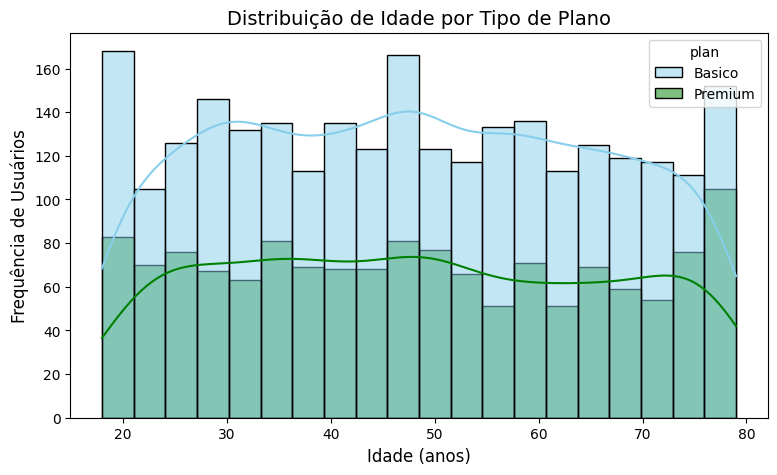

In [50]:

# Histograma para visualizar a idade (age)
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=20, kde=True)
plt.title('Distribuição de Idade por Tipo de Plano', fontsize=14)
plt.xlabel('Idade (anos)', fontsize=12)
plt.ylabel('Frequência de Usuários', fontsize=12)
plt.show()


💡Insights:

   Distribuição:
- Tipo de distribuição: Distribuição aproximadamente simétrica / uniforme, cobrindo dos 18 aos 79 anos com maior densidade ao redor da mediana (47 anos).
- Comportamento por plano: Não existe um padrão ou diferença etária expressiva entre os planos. 

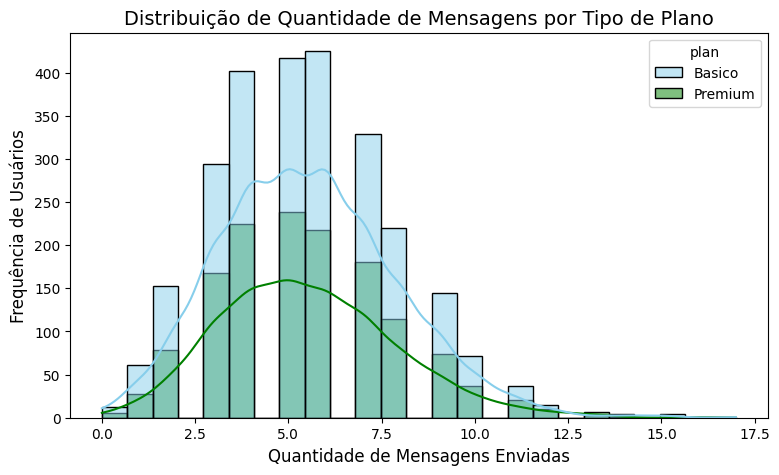

In [51]:
# Histograma para visualizar quant_mensagens
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='quant_mensagens', hue='plan', palette=['skyblue', 'green'], bins=25, kde=True)
plt.title('Distribuição de Quantidade de Mensagens por Tipo de Plano', fontsize=14)
plt.xlabel('Quantidade de Mensagens Enviadas', fontsize=12)
plt.ylabel('Frequência de Usuários', fontsize=12)
plt.show()


💡Insights:
- Tipo de distribuição:
Apresenta uma distribuição moderadamente assimétrica à direita (positiva), com a grande maioria dos clientes concentrada entre 3 e 8 mensagens (pico/moda em 5 a 6 mensagens) e uma cauda mais longa que se estende até cerca de 17 mensagens.

- Comparação entre os planos (plan):
Não existe um padrão de diferença relevante entre os planos: tanto os usuários do plano Básico quanto os do Premium apresentam curvas de comportamento muito semelhantes, com pico e variação parecidos.

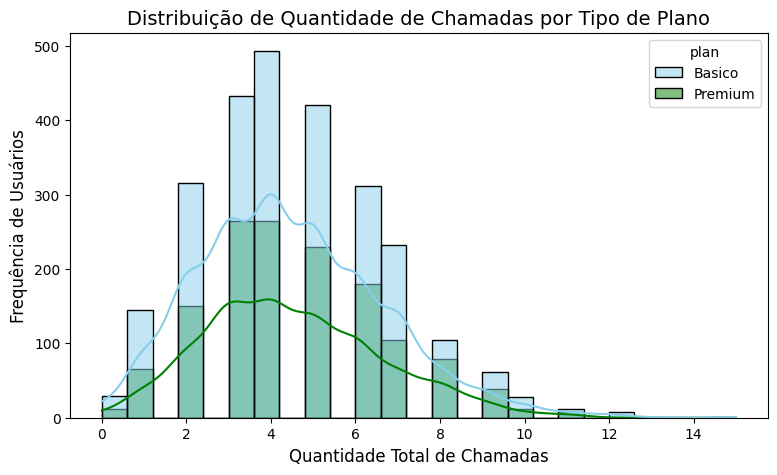

In [51]:
# Histograma para visualizar quant_chamadas
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='quant_chamadas', hue='plan', palette=['skyblue', 'green'], bins=25, kde=True)
plt.title('Distribuição de Quantidade de Chamadas por Tipo de Plano', fontsize=14)
plt.xlabel('Quantidade Total de Chamadas', fontsize=12)
plt.ylabel('Frequência de Usuários', fontsize=12)
plt.show()


💡Insights:

-Tipo de distribuição:
Apresenta formato unimodal próximo a uma curva em sino, com leve assimetria à direita (positiva). A maior concentração de usuários está entre 2 e 6 chamadas, tendo seu pico (moda) em 4 chamadas, e uma cauda que vai gradualmente diminuindo até 12–14 chamadas.

-Comparação entre os planos (plan):
Não existe um padrão de diferenciação claro entre os planos: o comportamento de ligações de usuários do plano Básico e do Premium é praticamente idêntico em formato e dispersão.
A maior altura das barras do plano Básico reflete apenas o fato de ele possuir mais usuários cadastrados na empresa (65% da base total), e não uma frequência relativa maior de uso. Clientes do plano Premium não fazem consideravelmente mais chamadas do que os clientes do plano Básico.

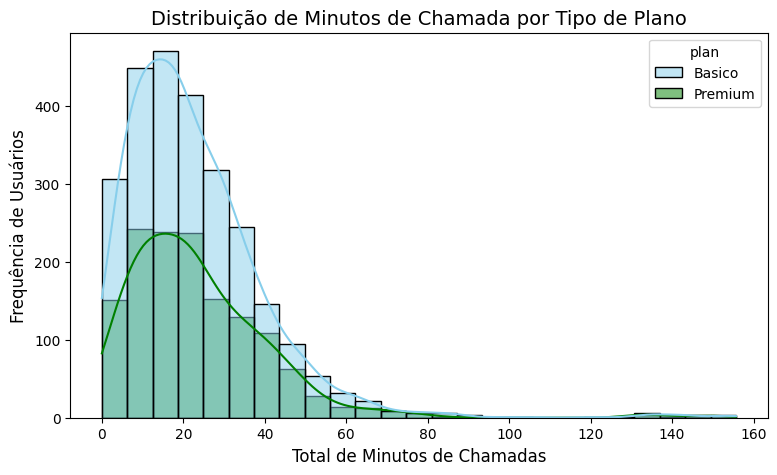

In [52]:
# Histograma para visualizar quant_minutos_chamada
col_minutos = 'total_minutos_chamada' if 'total_minutos_chamada' in user_profile.columns else 'quant_minutos_chamada'

plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x=col_minutos, hue='plan', palette=['skyblue', 'green'], bins=25, kde=True)
plt.title('Distribuição de Minutos de Chamada por Tipo de Plano', fontsize=14)
plt.xlabel('Total de Minutos de Chamadas', fontsize=12)
plt.ylabel('Frequência de Usuários', fontsize=12)
plt.show()


💡Insights:

-Tipo de distribuição:
Apresenta uma forte assimetria à direita (positiva). A grande maioria dos clientes acumula entre 10 e 35 minutos de chamadas (com o pico/moda entre 10 e 20 minutos), seguida por uma cauda longa que vai se afunilando até cerca de 80 minutos, com casos raros e isolados chegando a 140–160 minutos.

-Comparação entre os planos (plan):
Não existe uma diferença significativa de padrão entre os planos: os clientes do plano Premium não falam necessariamente mais tempo que os do plano Básico; ambas as curvas de densidade (KDE) têm exatamente o mesmo formato e o mesmo ápice de consumo.
Usuários de ambos os planos mantêm um perfil conservador de consumo de minutos, predominantemente abaixo de 40 minutos mensais.
A diferença visível na altura das barras decorre apenas da maior proporção de usuários cadastrados no plano Básico (65% da base total).


### 5.2 Identificação de outliers

🎯 **Objetivo:**  
Detectar valores extremos nas variáveis principais de **uso** e **clientes** que poderiam afetar a análise e decidir se exigem limpeza ou revisão adicional.

**Instruções:**  
- Use **boxplots** para identificar visualmente outliers nas seguintes colunas:  
  - `age`
  - `quant_mensagens`
  - `quant_chamadas`
  - `total_minutos_chamada`  
- Crie um **for** para gerar os 4 boxplots automaticamente.
<br>

- Depois de criar os gráficos, responda se **existem ou não outliers** nas variáveis.  
- Se houver outliers, crie outro loop para calcular os limites dessas colunas usando o **método IQR** e decida o que fazer com eles.
  - Se houver outliers em apenas um lado, não é necessário calcular ambos os limites.

**Dica:**
- Dentro do loop, use `plt.title(f'Boxplot: {col}')` para que o título mude de acordo com a coluna.

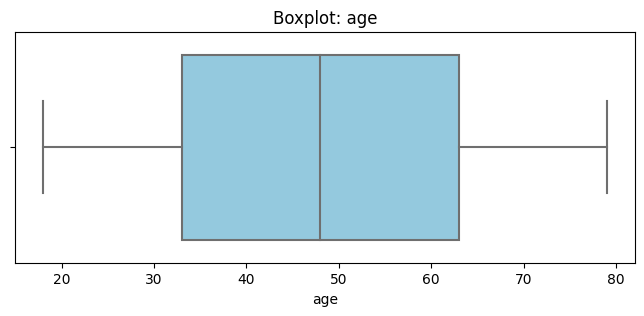

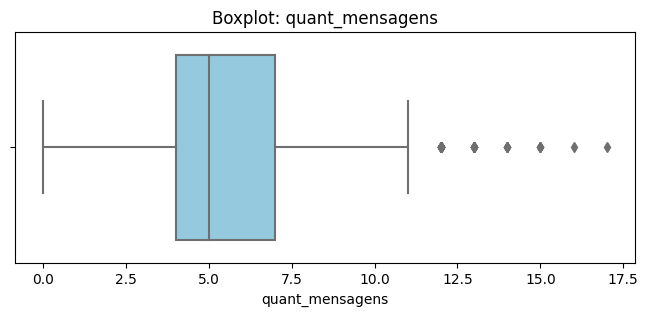

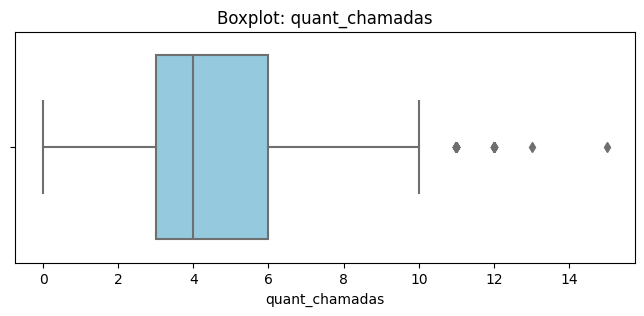

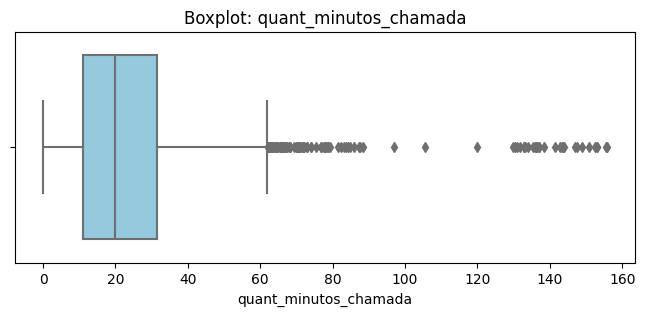

In [53]:
# Visualizar usando BoxPlot
columnas_numericas = ['age', 'quant_mensagens', 'quant_chamadas', 'quant_minutos_chamada']

# Loop para gerar os 4 boxplots
for col in columnas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}', fontsize=12)
    plt.xlabel(col)
    plt.show()

💡Insights:

-Age: Não apresenta outliers. A distribuição é homogênea e contínua de 18 a 79 anos (mediana em 48 anos), sem nenhuma anomalia.

-Quant_mensagens: Poucos outliers superiores (acima de 11 msgs). A grande maioria envia de 4 a 7 mensagens; o consumo máximo é de apenas 17 mensagens (perfeitamente plausível).

-Quant_chamadas: Poucos outliers superiores (acima de 10 chamadas). A concentração é grande entre 3 e 6 ligações, com pico máximo em 15 chamadas (comportamento normal).

-Quant_minutos_chamada: É a variável que mais chama atenção! Apresenta uma longa trilha de outliers superiores (de 60 até 160 minutos), evidenciando clientes intensivos (heavy users) que falam até 2,5 horas por mês.

In [55]:

# Calcular limites com o método IQR
colunas_limites = ['quant_mensagens', 'quant_chamadas', 'quant_minutos_chamada']
for col in colunas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"--- {col} ---")
    print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"Limite Superior (IQR): {limite_superior:.2f}\n")

--- quant_mensagens ---
Q1: 4.00 | Q3: 7.00 | IQR: 3.00
Limite Superior (IQR): 11.50

--- quant_chamadas ---
Q1: 3.00 | Q3: 6.00 | IQR: 3.00
Limite Superior (IQR): 10.50

--- quant_minutos_chamada ---
Q1: 11.12 | Q3: 31.41 | IQR: 20.30
Limite Superior (IQR): 61.86



In [56]:
# Revise os limites superiores e o max para decidir se mantém os outliers ou não
user_profile[colunas_limites].describe()

,quant_mensagens,quant_chamadas,quant_minutos_chamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

quant_mensagens (manter ou não os outliers, por quê?):
Manter. O limite superior é 11,50 e o valor máximo é de apenas 17 mensagens. Enviar 17 SMS ao longo de um mês é um comportamento comum e perfeitamente realista, sem indicar erro de coleta.


quant_chamadas (manter ou não os outliers, por quê?):
Manter. O limite superior é 10,50 e o valor máximo observado é 15 chamadas. Realizar 15 ligações no mês (1 ligação a cada 2 dias) é um padrão totalmente plausível de uso real.

quant_minutos_chamada (manter ou não os outliers, por quê?):
Manter. O limite superior é 61,86 min e o máximo atinge 155,69 min. Acumular 156 minutos em 30 dias equivale a apenas 2,5 horas de conversação no mês inteiro (5 min/dia). Trata-se de clientes de uso intensivo (heavy users) reais, indispensáveis para a análise de receita e franquia da operadora.

---

## 🧩 Etapa 6: Segmentação de clientes

### 6.1 Segmentação de clientes por uso

🎯 **Objetivo:** Classificar cada usuário em um grupo de uso (Baixo uso, Uso médio, Alto uso) com base na quantidade de chamadas e mensagens registradas.

**Instruções:**  
- Crie uma nova coluna chamada `grupo_uso` no dataframe `user_profile`.
- Use comparações lógicas (<, >) para avaliar as condições de chamadas e mensagens e atribua:
  - `'Baixo uso'` quando chamadas < 5 e mensagens < 5
  - `'Uso médio'` quando chamadas < 10 e mensagens < 10
  - `'Alto uso'` para os demais casos

In [57]:
# Criar coluna grupo_uso
def categorizar_uso(row):
    if row['quant_chamadas'] < 5 and row['quant_mensagens'] < 5:
        return 'Baixo uso'
    elif row['quant_chamadas'] < 10 and row['quant_mensagens'] < 10:
        return 'Uso médio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(categorizar_uso, axis=1)



In [58]:
# verificar alterações
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,quant_mensagens,quant_chamadas,quant_minutos_chamada,grupo_uso
0,10000,Carlos,Santos,38.0,São Paulo,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso médio
1,10001,Matheus,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso
2,10002,Valentina,Souza,57.0,Brasília,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso médio
3,10003,Matheus,Souza,69.0,Rio de Janeiro,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso
4,10004,Matheus,Torres,63.0,Fortaleza,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Baixo uso


### 6.2 Segmentação de clientes por idade

🎯 **Objetivo:**: Classificar cada usuário em um grupo por **idade**.

**Instruções:**  
- Crie uma nova coluna chamada `grupo_idade` no dataframe `user_profile`.
- Use comparações lógicas (<, >) para avaliar as condições e atribua:
  - `'Jovem'` quando age < 30
  - `'Adulto'` quando age < 60
  - `'Idoso'` para os demais casos

In [59]:
# Criar coluna grupo_idade
def classificar_idade(age):
    if age < 30:
        return 'Jovem'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Idoso'
user_profile['grupo_idade'] = user_profile['age'].apply(classificar_idade)



In [60]:
# verificar alterações
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,quant_mensagens,quant_chamadas,quant_minutos_chamada,grupo_uso,grupo_idade
0,10000,Carlos,Santos,38.0,São Paulo,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso médio,Adulto
1,10001,Matheus,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Valentina,Souza,57.0,Brasília,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso médio,Adulto
3,10003,Matheus,Souza,69.0,Rio de Janeiro,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso,Idoso
4,10004,Matheus,Torres,63.0,Fortaleza,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Baixo uso,Idoso


### 6.3 Visualização da segmentação de clientes

🎯 **Objetivo:** Visualizar a distribuição dos usuários de acordo com os grupos criados: **grupo_uso** e **grupo_idade**.

**Instruções:**  
- Crie dois gráficos para as variáveis categóricas `grupo_uso` e `grupo_idade`.
- Adicione título e etiquetas aos eixos em cada gráfico.

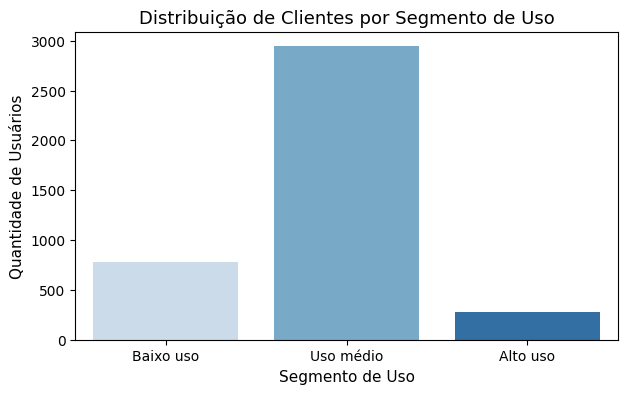

In [64]:
# Visualização dos segmentos por uso
plt.figure(figsize=(7, 4))
sns.countplot(
    data=user_profile, 
    x='grupo_uso', 
    order=['Baixo uso', 'Uso médio', 'Alto uso'],
    palette='Blues'
)
plt.title('Distribuição de Clientes por Segmento de Uso', fontsize=13)
plt.xlabel('Segmento de Uso', fontsize=11)
plt.ylabel('Quantidade de Usuários', fontsize=11)
plt.show()

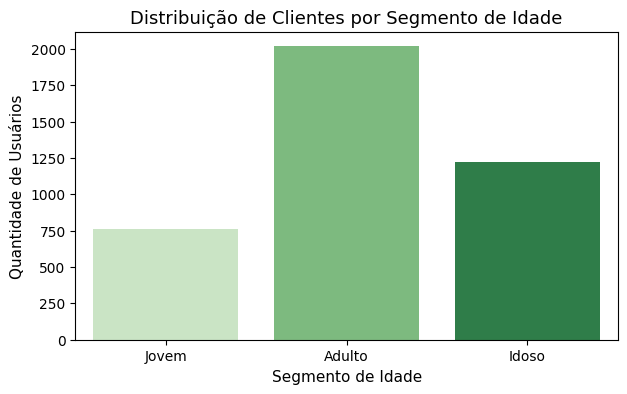

In [65]:
# Visualização dos segmentos por idade
plt.figure(figsize=(7, 4))
sns.countplot(
    data=user_profile, 
    x='grupo_idade', 
    order=['Jovem', 'Adulto', 'Idoso'],
    palette='Greens'
)

plt.title('Distribuição de Clientes por Segmento de Idade', fontsize=13)
plt.xlabel('Segmento de Idade', fontsize=11)
plt.ylabel('Quantidade de Usuários', fontsize=11)

plt.show()



---
## 🧩 Etapa 7: Insight Executivo para Stakeholders

🎯 **Objetivo:** Traduzir os achados da análise em conclusões acionáveis para o negócio, com foco em segmentação, padrões de uso e oportunidades comerciais.

**Perguntas a responder:**
- Quais problemas os dados tinham originalmente? Que porcentagem, ou quantidade de linhas, essa coluna representava?


- Quais segmentos de clientes você identificou e como eles se comportam de acordo com sua idade e nível de uso?  
- Quais segmentos parecem mais valiosos para a ConnectaTel e por quê?  
- Quais padrões de uso extremo (outliers) você encontrou e o que eles implicam para o negócio?


- Quais recomendações você faria para melhorar a oferta atual de planos ou criar novos planos com base nos segmentos e padrões detectados?

✍️ **Escreva aqui sua análise executiva:**
🔍 Segmentos por idade
Definição dos Segmentos (grupo_idade):

Jovem: Clientes com idade inferior a 30 anos (age < 30).
Adulto: Clientes de 30 a 59 anos (30 <= age < 60).
Idoso: Clientes com 60 anos ou mais (age >= 60).

📊 Segmentos por nível de uso
Definição dos Segmentos (grupo_uso):

Baixo uso: Clientes com menos de 5 chamadas e menos de 5 mensagens no mês.
Uso médio: Clientes com consumo intermediário (menos de 10 chamadas e menos de 10 mensagens, excetuando o baixo uso).
Alto uso: Clientes de uso intensivo que realizaram 10 ou mais chamadas e/ou enviaram 10 ou mais mensagens.


### Análise executiva

⚠️ **Problemas detectados nos dados**
1. Valores Sentinela e Preenchimentos Inválidos: Identificou-se o valor -999 na coluna age (tabela users), usado como preenchimento incorreto que distorcia a média e o desvio padrão da idade. Na coluna city, encontraram-se 96 registros preenchidos com o caractere '?'.
2. Tratamento de Cidades Ausentes: Ao somar os 96 registros com '?' aos 469 valores nulos legítimos , totalizaram-se 565 clientes sem município informado. Todos foram padronizados sob a categoria 'Desconhecido'.
3. Status de Retenção dos Clientes (churn_date): Os 3.534 registros nulos ($88,35\%$) na coluna churn_date não indicam falha na coleta, mas sim clientes ativos. Apenas 466 usuários ($11,65\%$) cancelaram o serviço no período analisado.
4. Inconsistências Temporais (reg_date e usage): Foram identificados $40$ cadastros datados no ano de $2026$. Por ultrapassarem a janela histórica da base (que vai até $2024$), foram identificados como erro de digitação/captura e convertidos para NaT. Na tabela usage, descartaram-se $50$ linhas com data ausente (0,12%) por inviabilizarem a alocação mensal do consumo.
5. Ausência Estrutural por Tipo de Consumo: A presença de nulos em duration (55%) e length(45%) na tabela usage reflete a própria regra do produto: mensagens de texto não possuem duração em minutos, assim como chamadas telefônicas não possuem comprimento de texto.


🔍 **Segmentos por idade** 


Principais Observações e Comportamento:

1. Predomínio do público adulto: O segmento Adulto constitui a maior fatia da base de clientes da ConnectaTel, refletindo a mediana de idade da empresa (em torno de 48 anos). Jovens e idosos distribuem-se de maneira equilibrada nas pontas.
2. Independência na escolha do plano: A adesão aos planos Básico (~65%) e Premium (~35%) mantém praticamente a mesma proporção em todos os três grupos. Jovens não contratam mais o Premium do que idosos, demonstrando que a idade, por si só, não é o fator que define a escolha do plano.

📊 **Segmentos por nível de uso**
1. Comportamento:
- Concentração no consumo moderado: A grande maioria da base de clientes se enquadra nos segmentos de Baixo uso e Uso médio. O usuário típico da ConnectaTel faz em média de 3 a 5 chamadas e envia de 4 a 7 mensagens por mês.
- O grupo de 'Alto uso': Embora represente a menor parcela de clientes em volume absoluto, é esse grupo que concentra os picos de consumo e a longa cauda de minutos.

2. Impacto no faturamento e planos:  
- Clientes de Alto uso que estão no plano Básico frequentemente estouram a franquia contratada, gerando receita adicional de excedente, mas correndo risco de insatisfação.
- Clientes de Baixo uso que estão no plano Premium subutilizam a franquia contratada, o que pode representar uma oportunidade de economia que eles próprios podem buscar via upgrade.


➡️ Isso sugere que ...


💡 **Recomendações**
1. Campanha Direta de Migração:

Ação: Mapear os clientes do plano Básico que apresentam alto consumo (acima de 60 minutos) e oferecer a mudança para o plano Premium.

Impacto: Evita surpresas na conta por excedente de consumo, melhora a experiência do cliente e reduz os cancelamentos.

2. Criação de um Plano Intermediário (Plano Controle):

Ação: Lançar uma opção intermediária sob medida para o perfil de consumo médio (cerca de 10 a 15 chamadas, 15 a 20 mensagens e 60 a 80 minutos).

Impacto: Preenche a lacuna entre o pacote Básico e o Premium, capturando clientes dispostos a pagar um pouco mais sem precisar contratar a opção mais cara.

---

## 🧩 Etapa 8: Carregar seu notebook e README no GitHub

🎯 **Objetivo:**  
Entregar sua análise de forma **profissional**, **documentada** e **versionada**, garantindo que qualquer pessoa possa revisar, executar e entender seu trabalho.



### Opção A: Enviar arquivos pela interface do GitHub (UI)

1. Baixe este notebook (`File → Download .ipynb`).  
2. Acesse seu repositório no GitHub (por exemplo, `telecom-analysis` ou `sprint-project`).  
3. Envie seu notebook em **Add file → Upload files**.  

---

### Opção B: Salvar direto pelo Google Colab

1. Abra seu notebook no Colab.  
2. Acesse **File → Save a copy in GitHub**.  
3. Selecione o repositório e a pasta correta (ex.: `notebooks/`).  
4. Escreva uma mensagem de commit clara, por exemplo:  
    - `feat: add final ConnectaTel analysis`
    - `adicionar versão final: Análise ConnectaTel`
5. Verifique no GitHub se o arquivo ficou no local correto e se o histórico de commits está limpo.

---


Adicione um arquivo `README.md` que descreva de forma clara:
- o objetivo do projeto,  
- os datasets utilizados,  
- as etapas da análise realizadas,  
- como executar o notebook (por exemplo, abri-lo no Google Colab),  
- uma breve guia de reprodução.

---


Link para o repositório público do projeto: `LINK para seu repo aqui`